In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sn
import sys
from pathlib import Path
import os
import math
import matplotlib.pyplot as plt
import matplotlib as mpl
import datetime as dt

from sklearn.metrics import accuracy_score

In [14]:
results_df = pd.read_csv("/disk/atlas3/users/agrefsru/imcalML/results/xgboost_hyperparams/high-level_SPH_9_BH_n4_M8_BH_n2_M10_BH_n4_M10_BH_n6_M10_BH_n4_M12_CUT.csv")
delta_t = np.zeros(len(results_df))
for i in range(len(results_df)):
    delta_t[i] = float(results_df["Training time"].values[i][2:7].replace(":", "."))
results_df["Delta_t"] = delta_t

results_df = results_df.drop(columns=["Training time", "Time", "Unnamed: 0"])

col_order_1 = ["lr", "max_depth", "gamma", "lambda", "alpha", "subsample_f", "colsample_f", "ACC", "LogLoss", "Delta_t", "n_trees"]
col_order_2 = ["lr", "max_depth", "gamma", "lambda", "alpha", "subsample_f", "colsample_f", "LogLoss", "Loss_train", "Loss_val", "ACC", "ACC_val", "ACC_train"]
sample_labels = ["SPH_9", "BH_n4_M8", "BH_n2_M10", "BH_n4_M10", "BH_n6_M10", "BH_n4_M12"]
sample_metrics = [f"ACC_{label}" for label in sample_labels]
col_order_3 = ["lr", "max_depth", "gamma", "lambda", "alpha", "subsample_f", "colsample_f", ] + sample_metrics

results_df[0:5]

,lr,max_depth,gamma,lambda,alpha,subsample_f,colsample_f,ACC,LogLoss,ACC_SPH_9,...,ACC_BH_n2_M10,ACC_BH_n4_M10,ACC_BH_n6_M10,ACC_BH_n4_M12,n_trees,ACC_train,ACC_val,Loss_train,Loss_val,Delta_t
0,0.01,1,0.0,0.0,0.0,0.25,0.25,0.457750,1.370072,0.868229,...,0.301803,0.106660,0.232150,0.678399,10000.0,0.492667,0.492667,1.292371,1.304795,2.24
1,0.01,1,0.0,0.0,0.0,0.25,0.50,0.459236,1.364597,0.865000,...,0.302025,0.110516,0.234404,0.685629,10000.0,0.495033,0.495033,1.286838,1.300481,2.24
2,0.01,1,0.0,0.0,0.0,0.25,0.75,0.461458,1.360423,0.867157,...,0.303096,0.112536,0.235284,0.689006,10000.0,0.496067,0.496067,1.284500,1.298742,2.25
3,0.01,1,0.0,0.0,0.0,0.25,1.00,0.460000,1.362123,0.865506,...,0.306760,0.113055,0.232734,0.684400,10000.0,0.496117,0.496117,1.282966,1.297750,2.20
4,0.01,1,0.0,0.0,0.0,0.50,0.25,0.452292,1.379300,0.866995,...,0.302688,0.104261,0.227182,0.671380,10000.0,0.488783,0.488783,1.301087,1.313222,2.24


In [15]:
hyperparams = {
    "lr" : [0.01, 0.1],
    "max_depth" : [1, 2, 3, 4],
    "gamma" : [0, 0.1, 1],
    "lambda" : [0, 0.1, 1],
    "alpha" : [0, 0.1, 1],
    "subsample_f" : [0.25, 0.5, 0.75, 1],
    "colsample_f" : [0.25, 0.5, 0.75, 1]
}

hyperparams_labels = [r"$\eta$", r"$D_{max}$", r"$\gamma$", r"$\lambda$", r"$\alpha$", r"$f_N$", r"$f_x$"]

val_metrics = ["ACC", "LogLoss"]
comp_metrics = ["Delta_t", "n_trees"]
metrics = val_metrics + comp_metrics
metric_labels = ["ACC", "LogLoss", r"$\Delta t$", r"$M_{trees}$"]

<AxesSubplot: >

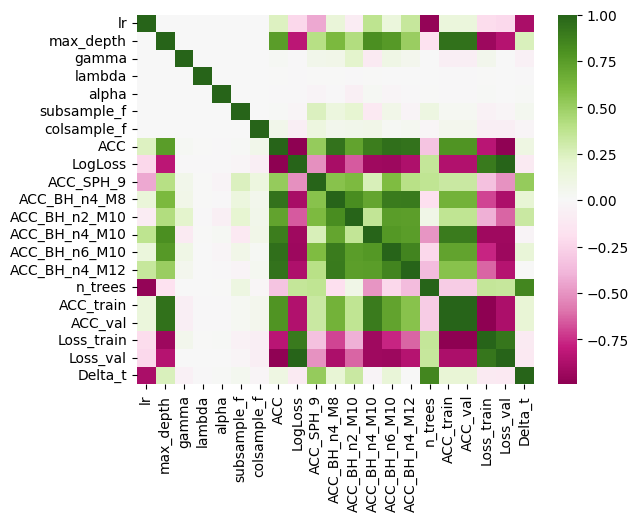

In [16]:
sn.heatmap(results_df.corr(), cmap="PiYG")

<AxesSubplot: >

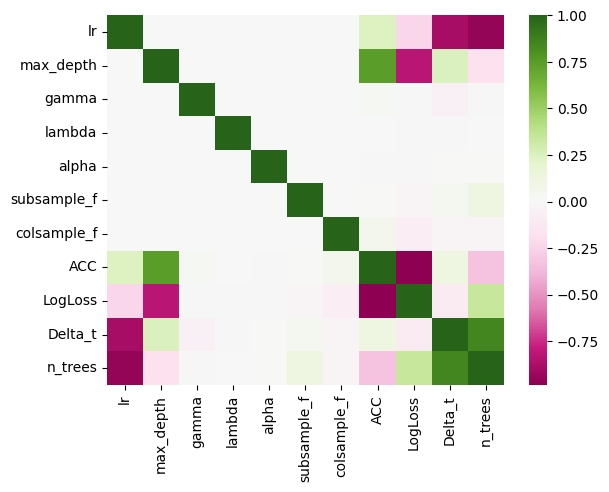

In [17]:
sn.heatmap(results_df[col_order_1].corr(method="pearson"), cmap="PiYG")


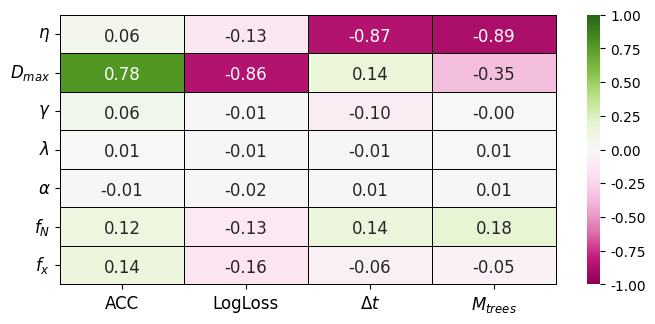

In [18]:
fig, ax = plt.subplots(1,1, figsize=(8, len(hyperparams_labels)*0.5))
results_1 = results_df[col_order_1].corr(method="spearman")
sn.heatmap(results_1.loc[hyperparams.keys(), metrics], cmap="PiYG", annot=True, 
            linewidth=0.5,
            linecolor='black',
            clip_on=False,
            fmt='.2f', 
            annot_kws={"va": 'center_baseline', "size": 12},
            vmin=-1,
            vmax=1,
            cbar = True,
            cbar_kws={'format': '%.2f'}, ax=ax)
ax.xaxis.set_ticklabels(metric_labels, size=12, rotation=0)
ax.yaxis.set_ticklabels(hyperparams_labels, size=12, rotation=0)
fig.savefig(f"../results/xgboost_hyperparams/XGBoost_hyperparam_corrs_1.pdf", format="pdf",bbox_inches='tight')

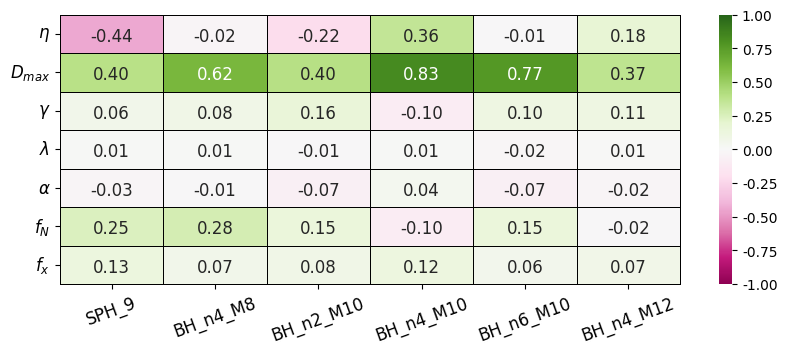

In [19]:
fig, ax = plt.subplots(1,1, figsize=(10, len(hyperparams_labels)*0.5))
results_3 = results_df[col_order_3].corr(method="spearman")
sn.heatmap(results_3.loc[hyperparams.keys(), sample_metrics], cmap="PiYG", annot=True, 
            linewidth=0.5,
            linecolor='black',
            clip_on=False,
            fmt='.2f', 
            annot_kws={"va": 'center_baseline', "size": 12},
            vmin=-1,
            vmax=1,
            cbar = True,
            cbar_kws={'format': '%.2f'}, ax=ax)
ax.xaxis.set_ticklabels(sample_labels, size=12, rotation=20)
ax.yaxis.set_ticklabels(hyperparams_labels, size=12, rotation=0)
fig.savefig(f"../results/xgboost_hyperparams/XGBoost_hyperparam_corrs_3.pdf", format="pdf",bbox_inches='tight')

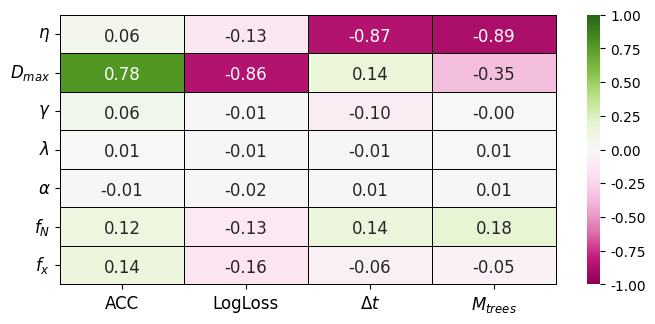

In [20]:
fig, ax = plt.subplots(1,1, figsize=(8, len(hyperparams_labels)*0.5))
results_1 = results_df[col_order_1].corr(method="spearman")
sn.heatmap(results_1.loc[hyperparams.keys(), metrics], cmap="PiYG", annot=True, 
            linewidth=0.5,
            linecolor='black',
            clip_on=False,
            fmt='.2f', 
            annot_kws={"va": 'center_baseline', "size": 12},
            vmin=-1,
            vmax=1,
            cbar = True,
            cbar_kws={'format': '%.2f'}, ax=ax)
ax.xaxis.set_ticklabels(metric_labels, size=12, rotation=0)
ax.yaxis.set_ticklabels(hyperparams_labels, size=12, rotation=0)
fig.savefig(f"../results/xgboost_hyperparams/XGBoost_hyperparam_corrs_1.pdf", format="pdf",bbox_inches='tight')

<AxesSubplot: >

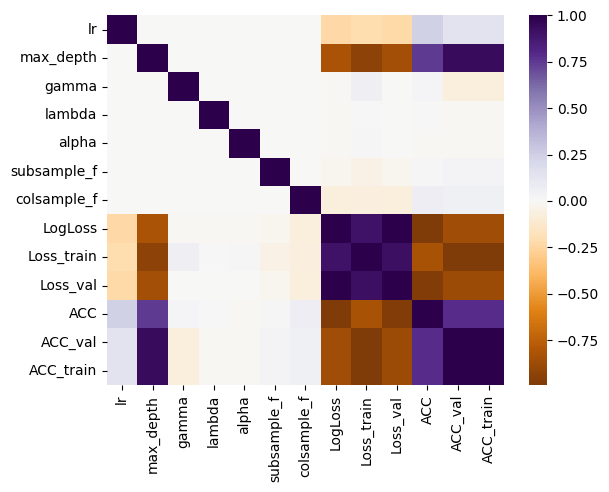

In [21]:
sn.heatmap(results_df[col_order_2].corr(method="pearson"), cmap="PuOr")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'Count')

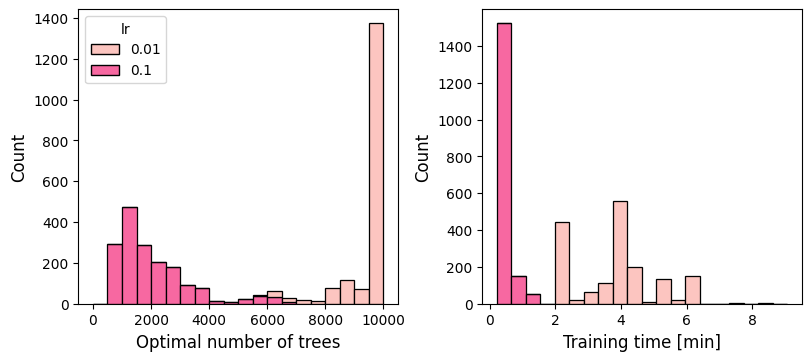

In [22]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize=(8, 3.5), layout="constrained")

sn.histplot(results_df, x="n_trees", hue="lr", ax=axs[0], bins=20, binrange=(0, 10000), palette=["#fcc5c0", "#f768a1"], alpha=1, multiple='stack')
axs[0].set_xlabel("Optimal number of trees", fontsize=12)
axs[0].set_ylabel("Count", fontsize=12)
sn.histplot(results_df, x="Delta_t", hue="lr", ax=axs[1], bins=20, palette=["#fcc5c0", "#f768a1"], alpha=1, multiple='stack')
axs[1].set_xlabel("Training time [min]", fontsize=12)
axs[1].legend().remove()
axs[1].set_ylabel("Count", fontsize=12)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


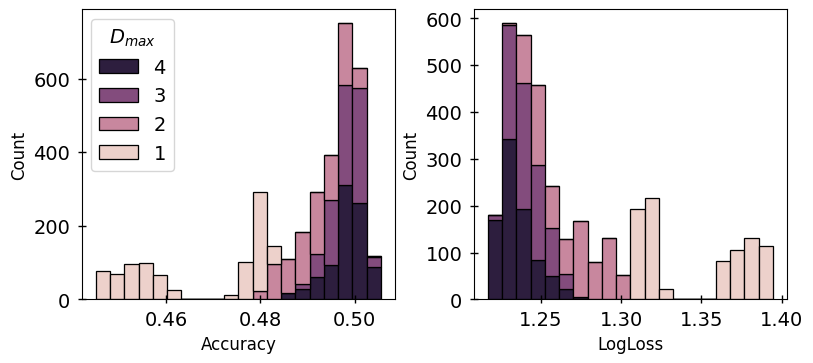

In [23]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize=(8, 3.5), layout="constrained")

sn.histplot(results_df, x="ACC", hue="max_depth", ax=axs[0], bins=20, 
            alpha=1, multiple='stack', legend=True)
axs[0].set_xlabel("Accuracy", fontsize=12)
axs[0].set_ylabel("Count", fontsize=12)

axs[0].legend(title=r"$D_{max}$", labels=[4, 3, 2, 1], fontsize=14, title_fontsize=14)

sn.histplot(results_df, x="LogLoss", hue="max_depth", ax=axs[1], bins=20, 
            alpha=1, multiple='stack')
axs[1].set_xlabel("LogLoss", fontsize=12)
axs[1].legend().remove()
axs[1].set_ylabel("Count", fontsize=12)

for ax in axs:
    ax.tick_params(which="both", direction="inout", bottom=True, left=True, labelsize=14, pad=5, length=4, width=1)
    ax.tick_params(which="major", length=6)
fig.savefig(f"../results/xgboost_hyperparams/XGBoost_hyperparam_Dmax.pdf", format="pdf",bbox_inches='tight')

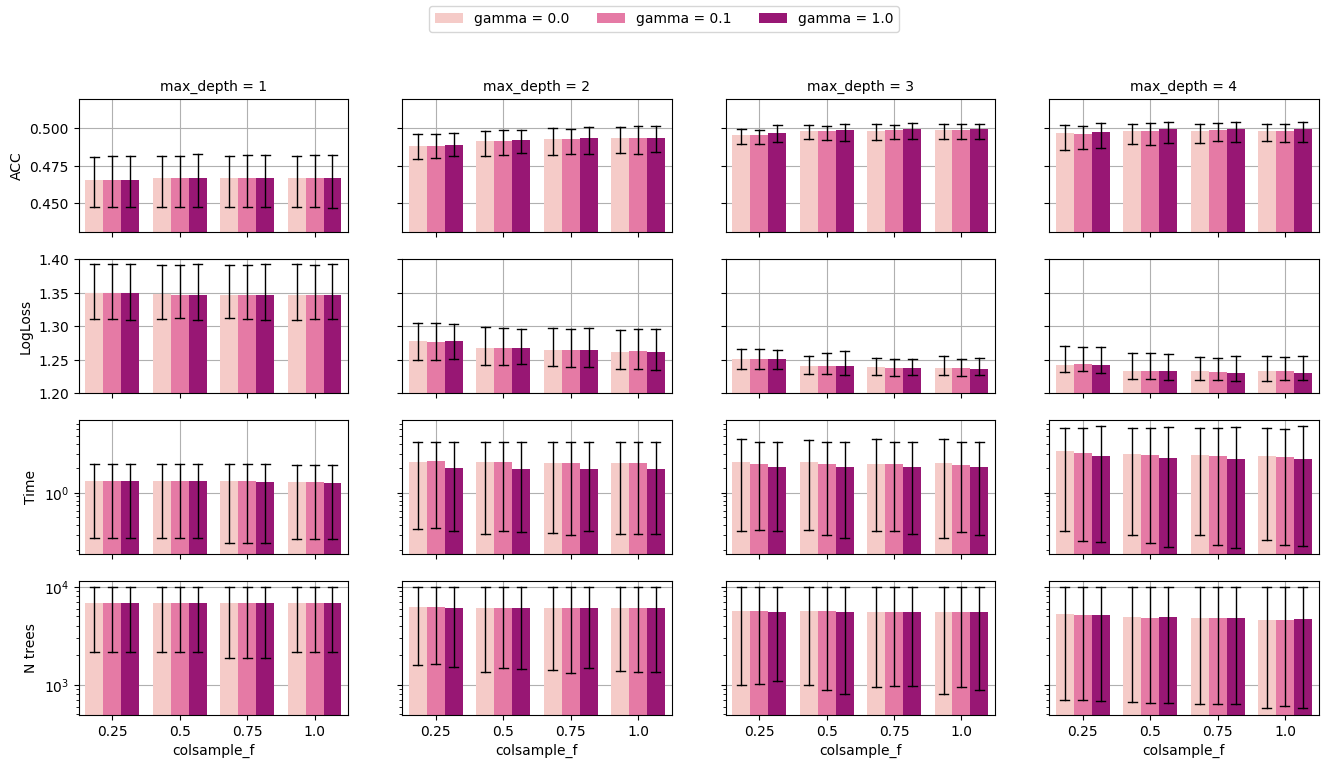

In [24]:

key = "max_depth"
hue_key = "gamma"
hue_palette=["#fcc5c0", "#f768a1", "#ae017e"]
fig, axs = plt.subplots(nrows = len(metrics), ncols = len(hyperparams[key]), sharex=True, sharey="row", 
                        figsize=(4*len(metrics), 2*len(hyperparams[key])))
for j in range(len(metrics)):
    metric_key = metrics[j]
    for i in range(len(hyperparams[key])):
        value = hyperparams[key][i]
        axs[0][i].set_title(f"{key} = {value}", fontsize=10)
        df_subset = results_df[results_df[key] == value]
        sn.barplot(df_subset, x="colsample_f", y=metric_key, ax=axs[j][i], hue = hue_key,
                                    errorbar=("pi", 95), capsize=.4, err_kws={"color": "black", "linewidth": 1},
                                    palette=hue_palette) 
    if metric_key == "ACC":
        for ax in axs[j]:
            ax.set_ylim(0.43, 0.52)
    elif metric_key == "LogLoss":
        for ax in axs[j]:
            ax.set_ylim(1.2, 1.4)
    elif metric_key == "n_trees":
        for ax in axs[j]:
            ax.set_ylabel("N trees")
            ax.set_yscale("log")
    elif metric_key == "Delta_t":
        for ax in axs[j]:
            ax.set_ylabel("Time")
            ax.set_yscale("log")
    
fig.suptitle(f"      ", x=0.1, va="top", fontsize=15)
handles, labels = axs[0][0].get_legend_handles_labels()
labels = [fr"{hue_key} = {label}" for label in labels]
fig.legend(handles, labels, loc='upper center', ncol=4, labelspacing=0.1, fontsize=10)

for ax in axs.flatten():
    #ax.set_xlabel(r"$N_\text{train}$")
    if ax.get_legend() != None:
        ax.get_legend().remove()
    ax.set_axisbelow(True)
    ax.grid(True)

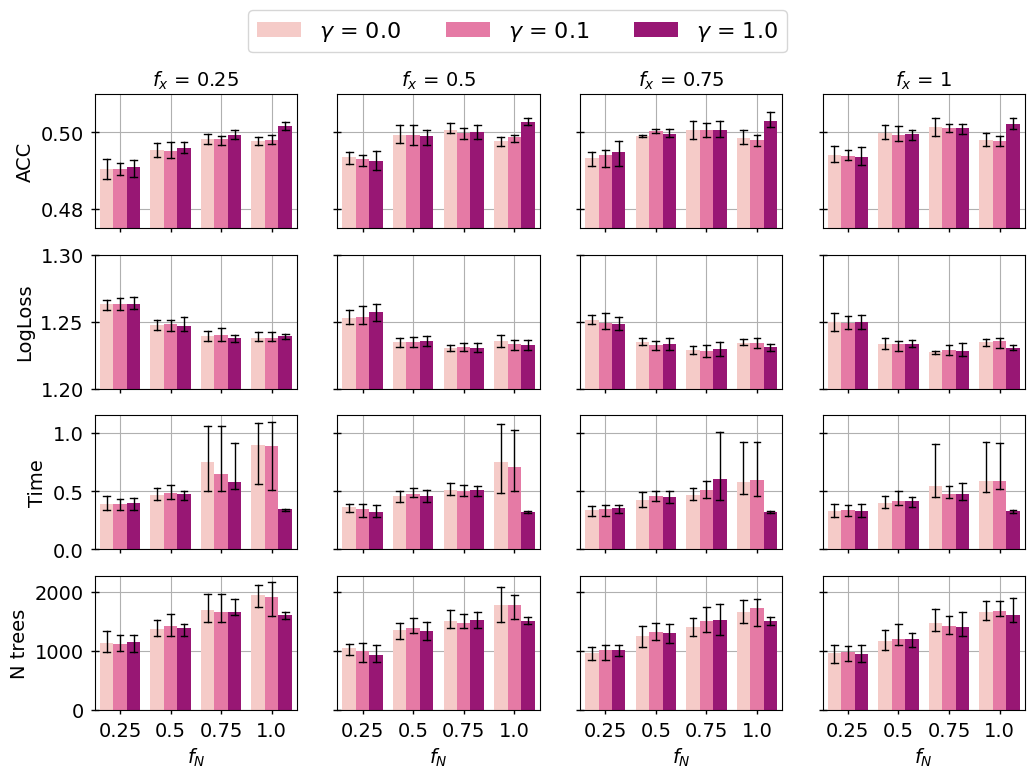

In [30]:

key = "colsample_f"
hue_key = "gamma"
hue_palette=["#fcc5c0", "#f768a1", "#ae017e"]
fig, axs = plt.subplots(nrows = len(metrics), ncols = len(hyperparams[key]), sharex=True, sharey="row", 
                        figsize=(3*len(metrics), 2*len(hyperparams[key])))
for j in range(len(metrics)):
    metric_key = metrics[j]
    for i in range(len(hyperparams[key])):
        value = hyperparams[key][i]
        axs[0][i].set_title(rf"$f_x$ = {value}", fontsize=14)
        df_subset = results_df[results_df["lr"] == 0.1]
        df_subset = df_subset[df_subset["max_depth"] == 3]
        df_subset = df_subset[df_subset[key] == value]
        sn.barplot(df_subset, x="subsample_f", y=metric_key, ax=axs[j][i], hue = hue_key,
                                    errorbar=("pi", 95), capsize=.4, err_kws={"color": "black", "linewidth": 1},
                                    palette=hue_palette) 
    if metric_key == "ACC":
        for ax in axs[j]:
            ax.set_ylabel("ACC", fontsize=14)
            ax.set_ylim(0.475, 0.51)
    elif metric_key == "LogLoss":
        for ax in axs[j]:
            ax.set_ylabel("LogLoss", fontsize=14)
            ax.set_ylim(1.2, 1.3)
    elif metric_key == "n_trees":
        for ax in axs[j]:
            ax.set_ylabel("N trees", fontsize=14)
            #ax.set_yscale("log")
    elif metric_key == "Delta_t":
        for ax in axs[j]:
            ax.set_ylabel("Time", fontsize=14)
            #ax.set_yscale("log")
    
fig.suptitle(f"      ", x=0.1, va="top", fontsize=15)
handles, labels = axs[0][0].get_legend_handles_labels()
labels = [fr"$\gamma$ = {label}" for label in labels]
fig.legend(handles, labels, loc='upper center', ncol=4, labelspacing=0.1, fontsize=16)

for ax in axs.flatten():
    #ax.set_xlabel(r"$N_\text{train}$")
    if ax.get_legend() != None:
        ax.get_legend().remove()
    ax.set_axisbelow(True)
    ax.grid(True)
    ax.tick_params(which="both", direction="inout", bottom=True, left=True, labelsize=14, pad=5, length=4, width=1)
    ax.tick_params(which="major", length=6)
    ax.set_xlabel(r"$f_N$", fontsize=14)

fig.savefig(f"../results/xgboost_hyperparams/XGBoost_hyperparam_details.pdf", format="pdf",bbox_inches='tight')

/tmp/ipykernel_31370/980137027.py:12: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sn.barplot(df_subset, x="gamma", y=metric_key, ax=axs[j][i], hue = hue_key,
/tmp/ipykernel_31370/980137027.py:12: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sn.barplot(df_subset, x="gamma", y=metric_key, ax=axs[j][i], hue = hue_key,
/tmp/ipykernel_31370/980137027.py:12: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sn.barplot(df_subset, x="gamma", y=metric_key, ax=axs[j][i], hue = hue_key,
/tmp/ipykernel_31370/980137027.py:12: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sn.barplot(df_subset, x="gamma", y=metric_key, ax=axs[j][i], hue = hue_key,
/tmp/ipykernel_31370/980137027.py:12: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sn.barplot(df_subset, x="g

/tmp/ipykernel_31370/980137027.py:12: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sn.barplot(df_subset, x="gamma", y=metric_key, ax=axs[j][i], hue = hue_key,
/tmp/ipykernel_31370/980137027.py:12: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sn.barplot(df_subset, x="gamma", y=metric_key, ax=axs[j][i], hue = hue_key,
/tmp/ipykernel_31370/980137027.py:12: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sn.barplot(df_subset, x="gamma", y=metric_key, ax=axs[j][i], hue = hue_key,
/tmp/ipykernel_31370/980137027.py:12: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sn.barplot(df_subset, x="gamma", y=metric_key, ax=axs[j][i], hue = hue_key,
/tmp/ipykernel_31370/980137027.py:12: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sn.barplot(df_subset, x="g

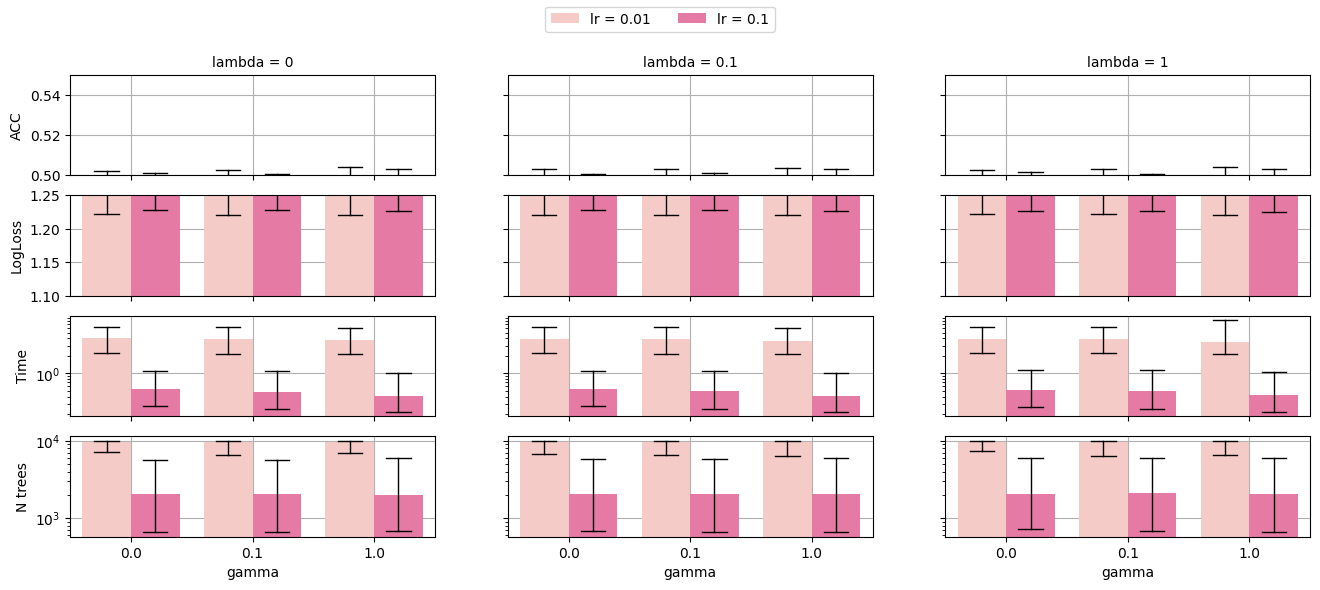

In [26]:

key = "lambda"
hue_key = "lr"
hue_palette=["#fcc5c0", "#f768a1", "#ae017e", "grey"][0:3]
fig, axs = plt.subplots(nrows = len(metrics), ncols = len(hyperparams[key]), sharex=True, sharey="row", 
                        figsize=(4*len(metrics), 2*len(hyperparams[key])))
for j in range(len(metrics)):
    metric_key = metrics[j]
    for i in range(len(hyperparams[key])):
        value = hyperparams[key][i]
        axs[0][i].set_title(f"{key} = {value}", fontsize=10)
        df_subset = results_df[results_df[key] == value]
        sn.barplot(df_subset, x="gamma", y=metric_key, ax=axs[j][i], hue = hue_key,
                                    errorbar=("pi", 95), capsize=.4, err_kws={"color": "black", "linewidth": 1},
                                    palette=hue_palette) 
    if metric_key == "ACC":
        for ax in axs[j]:
            ax.set_ylim(0.5, 0.55)
    elif metric_key == "LogLoss":
        for ax in axs[j]:
            ax.set_ylim(1.1, 1.25)
    elif metric_key == "n_trees":
        for ax in axs[j]:
            ax.set_ylabel("N trees")
            ax.set_yscale("log")
    elif metric_key == "Delta_t":
        for ax in axs[j]:
            ax.set_ylabel("Time")
            ax.set_yscale("log")
    
fig.suptitle(f"      ", x=0.1, va="top", fontsize=15)
handles, labels = axs[0][0].get_legend_handles_labels()
labels = [fr"{hue_key} = {label}" for label in labels]
fig.legend(handles, labels, loc='upper center', ncol=4, labelspacing=0.1, fontsize=10)

for ax in axs.flatten():
    #ax.set_xlabel(r"$N_\text{train}$")
    if ax.get_legend() != None:
        ax.get_legend().remove()
    ax.set_axisbelow(True)
    ax.grid(True)